In [1]:
# Análisis Exploratorio de Datos (EDA)
## Previsión de Demanda - PYMES de Alimentos Preparados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar datos
df = pd.read_excel('../data/raw/dataset_sintetico_demanda_lima.xlsx')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 730 filas, 7 columnas


,fecha,dia_semana,mes,es_festivo,temperatura_promedio,precipitacion_mm,demanda_real
0,2023-01-01,Sunday,1,1,20.986857,0.037124,286
1,2023-01-02,Monday,1,0,18.446943,4.913777,178
2,2023-01-03,Tuesday,1,0,21.590754,0.250562,194
3,2023-01-04,Wednesday,1,0,25.092119,1.718481,198
4,2023-01-05,Thursday,1,0,18.063387,0.640563,185


In [3]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 730 non-null    datetime64[ns]
 1   dia_semana            730 non-null    object        
 2   mes                   730 non-null    int64         
 3   es_festivo            730 non-null    int64         
 4   temperatura_promedio  730 non-null    float64       
 5   precipitacion_mm      730 non-null    float64       
 6   demanda_real          730 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 40.1+ KB


In [4]:
# Estadísticas descriptivas
df.describe()

,fecha,mes,es_festivo,temperatura_promedio,precipitacion_mm,demanda_real
count,730,730.000000,730.000000,730.000000,730.000000,730.000000
mean,2023-12-31 12:00:00,6.512329,0.038356,18.975361,2.070971,211.389041
min,2023-01-01 00:00:00,1.000000,0.000000,12.000000,0.009904,126.000000
25%,2023-07-02 06:00:00,4.000000,0.000000,16.207914,0.559294,186.000000
50%,2023-12-31 12:00:00,7.000000,0.000000,18.959561,1.492182,210.000000
75%,2024-06-30 18:00:00,9.750000,0.000000,21.510704,2.820686,235.750000
max,2024-12-30 00:00:00,12.000000,1.000000,28.000000,12.000000,326.000000
std,NaN,3.448303,0.192186,3.764814,2.058083,33.053009


In [5]:
# Verificar valores nulos
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print(f"Columnas con nulos: {len(nulls)}")
nulls

Columnas con nulos: 0


Series([], dtype: int64)

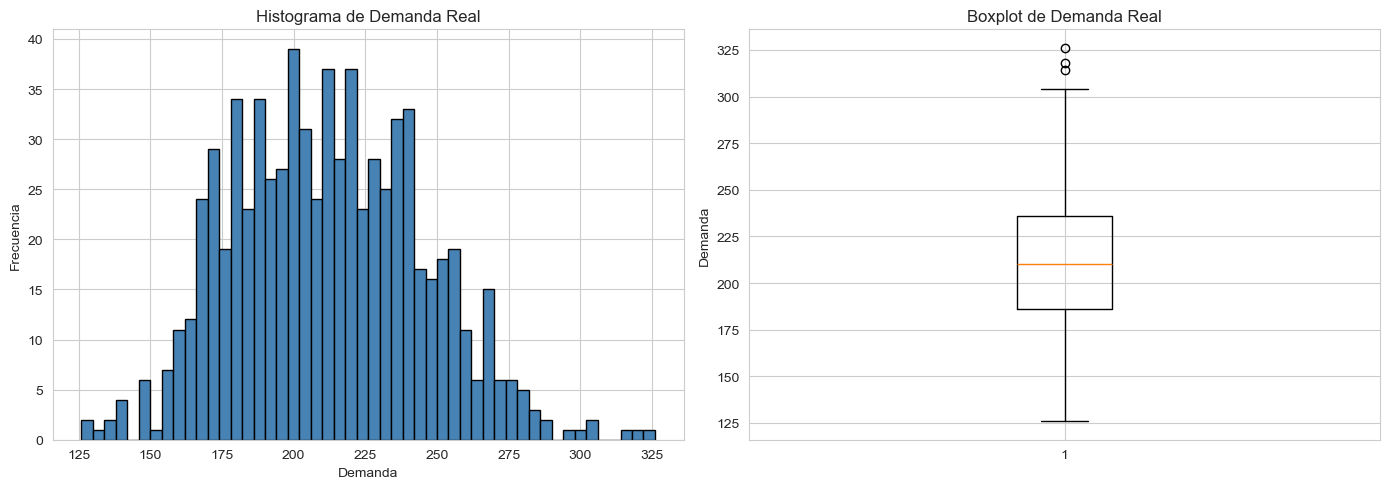

Media: 211.39
Mediana: 210.00
Desviación estándar: 33.05


In [6]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['demanda_real'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Histograma de Demanda Real')
axes[0].set_xlabel('Demanda')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['demanda_real'])
axes[1].set_title('Boxplot de Demanda Real')
axes[1].set_ylabel('Demanda')

plt.tight_layout()
plt.show()

print(f"Media: {df['demanda_real'].mean():.2f}")
print(f"Mediana: {df['demanda_real'].median():.2f}")
print(f"Desviación estándar: {df['demanda_real'].std():.2f}")

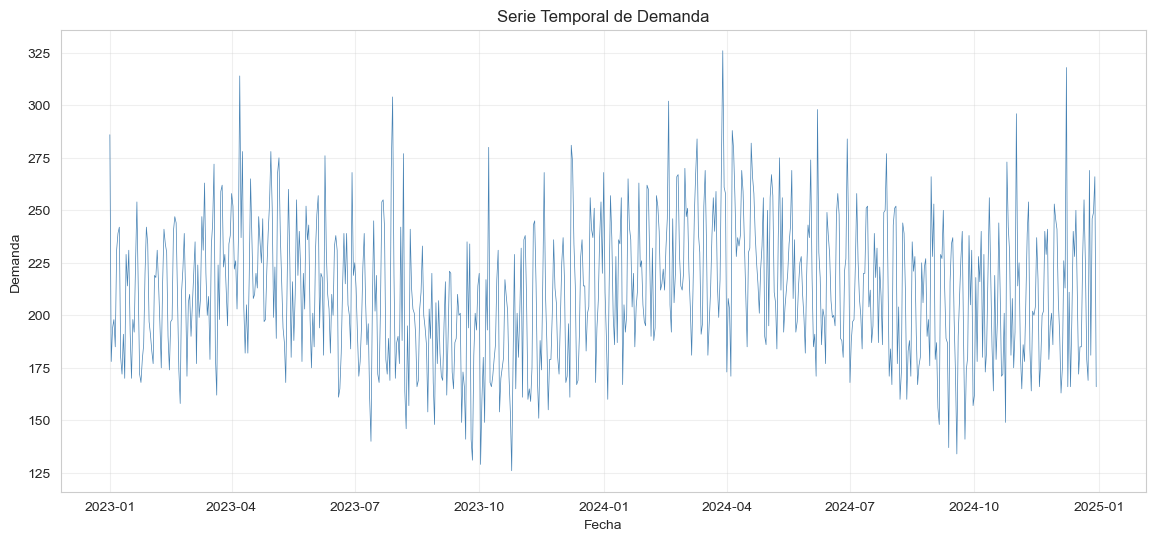

In [7]:
# Serie temporal completa
plt.figure(figsize=(14, 6))
plt.plot(df['fecha'], df['demanda_real'], color='steelblue', linewidth=0.5)
plt.title('Serie Temporal de Demanda')
plt.xlabel('Fecha')
plt.ylabel('Demanda')
plt.grid(True, alpha=0.3)
plt.show()

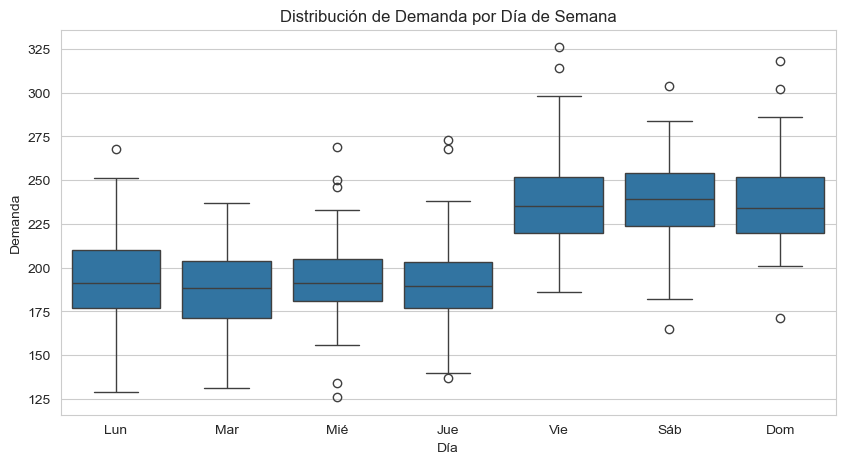

In [8]:
# Análisis de estacionalidad por día de semana
df['dia_semana'] = pd.to_datetime(df['fecha']).dt.dayofweek
dia_map = {0:'Lun',1:'Mar',2:'Mié',3:'Jue',4:'Vie',5:'Sáb',6:'Dom'}
df['dia_nombre'] = df['dia_semana'].map(dia_map)

plt.figure(figsize=(10, 5))
sns.boxplot(x='dia_nombre', y='demanda_real', data=df, order=['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'])
plt.title('Distribución de Demanda por Día de Semana')
plt.xlabel('Día')
plt.ylabel('Demanda')
plt.show()

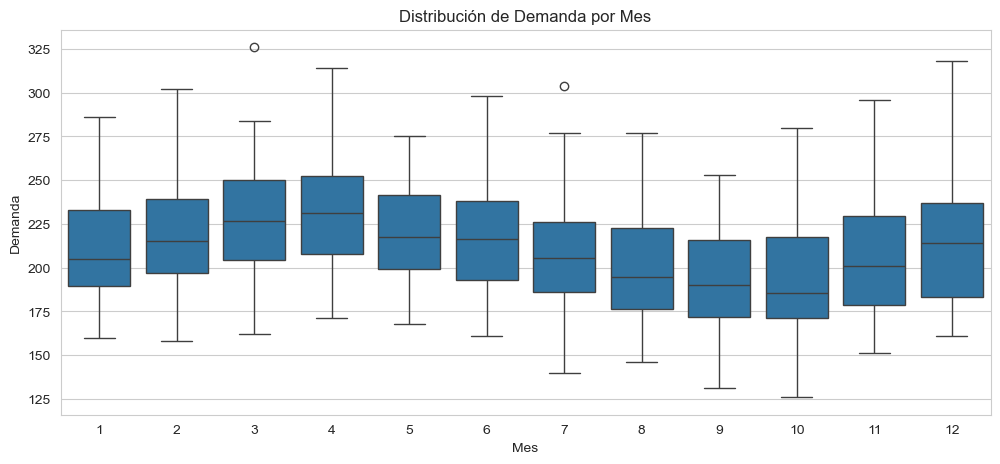

In [9]:
# Análisis de estacionalidad por mes
df['mes'] = pd.to_datetime(df['fecha']).dt.month

plt.figure(figsize=(12, 5))
sns.boxplot(x='mes', y='demanda_real', data=df)
plt.title('Distribución de Demanda por Mes')
plt.xlabel('Mes')
plt.ylabel('Demanda')
plt.show()

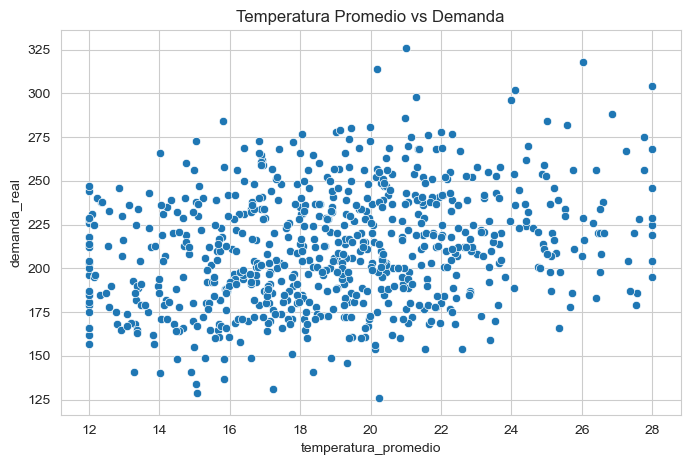

In [10]:
#Temperatura Vs Demanda
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='temperatura_promedio',
    y='demanda_real'
)
plt.title(
    'Temperatura Promedio vs Demanda'
)

plt.show()

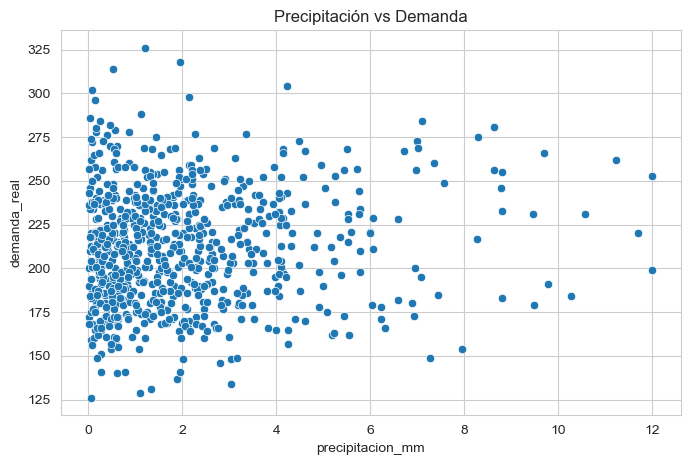

In [11]:
#Precipitación Vs Demanda
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='precipitacion_mm',
    y='demanda_real'
)

plt.title(
    'Precipitación vs Demanda'
)

plt.show()

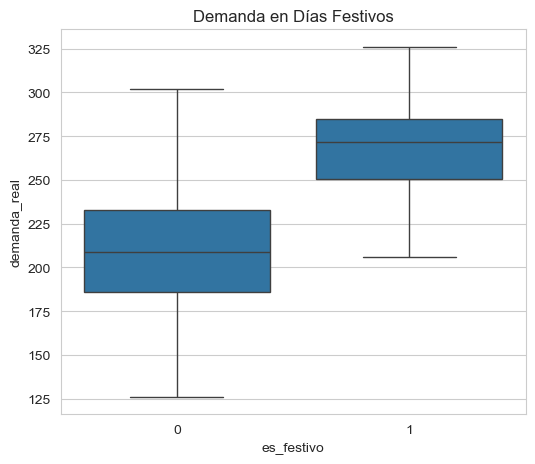

In [12]:
#Días Festivos Vs Demanda
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x='es_festivo',
    y='demanda_real'
)
plt.title(
    'Demanda en Días Festivos'
)
plt.show()

In [14]:
# Resumen EDA
print("=" * 50)
print("RESUMEN DE ANÁLISIS EXPLORATORIO")
print("=" * 50)
print(f"Período: {df['fecha'].min()} a {df['fecha'].max()}")
print(f"Días totales: {len(df)}")
print(f"Demanda promedio: {df['demanda_real'].mean():.2f}")
print(f"Demanda máxima: {df['demanda_real'].max():.2f}")
print(f"Demanda mínima: {df['demanda_real'].min():.2f}")
print(f"Desviación estándar: {df['demanda_real'].std():.2f}")
print(f"Coeficiente de variación: {(df['demanda_real'].std()/df['demanda_real'].mean())*100:.2f}%")

RESUMEN DE ANÁLISIS EXPLORATORIO
Período: 2023-01-01 00:00:00 a 2024-12-30 00:00:00
Días totales: 730
Demanda promedio: 211.39
Demanda máxima: 326.00
Demanda mínima: 126.00
Desviación estándar: 33.05
Coeficiente de variación: 15.64%
